<a href="https://colab.research.google.com/github/mruzair44/Deep-Learning/blob/main/Hybrid_Candlestick_Pattern_Recognition_and_Vision_Transformer%E2%80%93Based_Forecasting_for_Financial_Markets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Hybrid Candlestick Pattern Recognition and Vision Transformer–Based Forecasting for Financial Markets**

**Import & Utilities**

In [43]:
# Cell 1 — imports & utilities
import os, io, math, random, time
from typing import List, Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pywt
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# optional timm
try:
    import timm
    HAVE_TIMM = True
except Exception:
    HAVE_TIMM = False

print("timm available:", HAVE_TIMM)

# reproducibility
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(42)


timm available: True


**Data download & preprocessing (CSV loader + OHLC cleaning)**

In [29]:
def load_data(symbol="BTC-USD", start="2018-01-01", end="2025-01-01"):
    df = yf.download(symbol, start=start, end=end)
    df = df[['Open','High','Low','Close']]
    df.columns = ['open','high','low','close']
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df

df = load_data()
df.head()


[*********************100%***********************]  1 of 1 completed


,open,high,low,close
0,14112.200195,14112.200195,13154.700195,13657.200195
1,13625.000000,15444.599609,13163.599609,14982.099609
2,14978.200195,15572.799805,14844.500000,15201.000000
3,15270.700195,15739.700195,14522.200195,15599.200195
4,15477.200195,17705.199219,15202.799805,17429.500000


**Candlestick pattern detection (Advance Block, Doji Star, Evening Star) + evaluation helpers**

In [30]:
# Cell 3 — patterns.py equivalent
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

def detect_advance_block(df: pd.DataFrame) -> np.ndarray:
    res = np.zeros(len(df), dtype=bool)
    for i in range(2, len(df)):
        a, b, c = df.iloc[i-2], df.iloc[i-1], df.iloc[i]
        body_a = abs(a['close'] - a['open'])
        body_b = abs(b['close'] - b['open'])
        body_c = abs(c['close'] - c['open'])
        if (a['close'] > a['open']) and (b['close'] > b['open']) and (c['close'] > c['open']) \
           and (body_b < body_a) and (body_c < body_b):
            res[i] = True
    return res

def detect_doji_star(df: pd.DataFrame, body_ratio_thresh=0.02) -> np.ndarray:
    res = np.zeros(len(df), dtype=bool)
    for i in range(1, len(df)):
        prev, cur = df.iloc[i-1], df.iloc[i]
        prev_body = abs(prev['close'] - prev['open'])
        cur_body = abs(cur['close'] - cur['open'])
        gap = abs(cur['open'] - prev['close'])
        if prev_body > 0 and cur_body <= body_ratio_thresh * prev['open'] and gap > 0:
            res[i] = True
    return res

def detect_evening_star(df: pd.DataFrame, star_body_ratio=0.02) -> np.ndarray:
    res = np.zeros(len(df), dtype=bool)
    for i in range(2, len(df)):
        c1, c2, c3 = df.iloc[i-2], df.iloc[i-1], df.iloc[i]
        cond = (c1['close'] > c1['open']) and (abs(c2['close'] - c2['open']) <= star_body_ratio * c2['open']) \
               and (c3['close'] < c3['open']) and (c3['close'] < (c1['open'] + c1['close'])/2.0)
        if cond: res[i] = True
    return res

def evaluate_pattern(true_mask, pred_mask):
    # compute precision, recall, f1 for binary event detection across series
    if true_mask.sum() == 0:
        # nothing in true labels -> return zeros to avoid division problems
        return {'precision':0.0, 'recall':0.0, 'f1':0.0}
    p,r,f,_ = precision_recall_fscore_support(true_mask.astype(int), pred_mask.astype(int), average='binary', zero_division=0)
    return {'precision':float(p),'recall':float(r),'f1':float(f)}

# quick demo on downloaded df
df_cols = df.copy()
df_cols.columns = [c.lower() for c in df_cols.columns]
ab = detect_advance_block(df_cols); ds = detect_doji_star(df_cols); es = detect_evening_star(df_cols)
print("Detected events (counts):", {"advance_block":ab.sum(), "doji_star":ds.sum(), "evening_star":es.sum()})


Detected events (counts): {'advance_block': np.int64(43), 'doji_star': np.int64(1515), 'evening_star': np.int64(245)}


**4) Unit tests for pattern detection (run in notebook)**

In [33]:
def _make_row(o,h,l,c): return {'open':o,'high':h,'low':l,'close':c} # Fixed: added 'l' for low and 'c' for close

def test_patterns():
    # Advance block test
    # Corrected data to ensure decreasing body sizes: (1.4-1=0.4), (1.6-1.4=0.2), (1.7-1.6=0.1)
    rows = [
        _make_row(1,1.4,0.9,1.4),   # Body 0.4
        _make_row(1.4,1.6,1.3,1.6), # Body 0.2
        _make_row(1.6,1.7,1.5,1.7)  # Body 0.1
    ]
    df_test = pd.DataFrame(rows)
    assert detect_advance_block(df_test).sum() == 1

    # Doji star test
    rows = [_make_row(1,1.2,0.9,1.4), _make_row(1.5,1.52,1.45,1.51)]
    df_test = pd.DataFrame(rows)
    assert detect_doji_star(df_test, body_ratio_thresh=0.05)[1] == True

    # Evening star test
    rows = [_make_row(1,1.2,0.9,1.4), _make_row(1.41,1.42,1.4,1.405), _make_row(1.4,1.45,1.3,1.1)]
    df_test = pd.DataFrame(rows)
    assert detect_evening_star(df_test, star_body_ratio=0.02)[2] == True

    print("Pattern unit tests passed!")

test_patterns()

Pattern unit tests passed!


**5) Spectrogram pipeline — CWT (Morlet) + intensity row + visualization helpers**

Spec shape (scales+1, time): (128, 512)


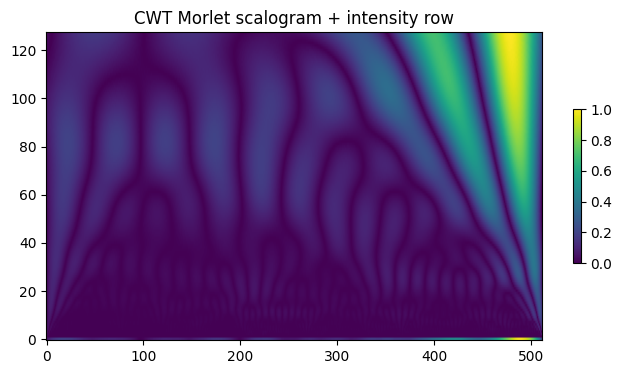

In [34]:

def series_to_cwt_image(series: np.ndarray, widths: np.ndarray = None, wavelet='morl') -> np.ndarray:
    # series should be 1D (e.g., normalized price history)
    if widths is None:
        widths = np.arange(1, min(128, max(8, len(series)//2)))
    coef, freqs = pywt.cwt(series, widths, wavelet)
    S = np.abs(coef)
    S = (S - S.min()) / (S.max() - S.min() + 1e-12)
    return S.astype(np.float32)

def add_intensity_row(S: np.ndarray) -> np.ndarray:
    intensity = S.sum(axis=0)
    intensity = (intensity - intensity.min()) / (intensity.max() - intensity.min() + 1e-12)
    S_aug = np.vstack([intensity[None, :], S])
    return S_aug

def plot_spec(S, title=None, figsize=(8,4)):
    plt.figure(figsize=figsize)
    plt.imshow(S, aspect='auto', origin='lower')
    if title: plt.title(title)
    plt.colorbar(shrink=0.5)
    plt.show()

# Demonstration: use last 512 samples from df
series = df_cols['close'].values.astype(float)
window = 512
if len(series) >= window:
    hist = series[-window:]
    base = hist[-1]
    hist_norm = hist / (base + 1e-12)
    S = series_to_cwt_image(hist_norm)
    S_aug = add_intensity_row(S)
    print("Spec shape (scales+1, time):", S_aug.shape)
    plot_spec(S_aug, "CWT Morlet scalogram + intensity row")
else:
    print("Series too short for demo. Reduce window.")


**Build sequences -> save .npz dataset (specs + targets)**

In [36]:
from pathlib import Path

def build_sequences_from_csv(csv_path: str, out_npz: str, window: int=512, horizon: int=20, step: int=8):
    df = pd.read_csv(csv_path)
    df.columns = [c.lower() for c in df.columns]
    close = df['close'].values.astype(float)
    N = len(close)
    specs = []
    targets = []
    meta = []
    for start in range(0, N - window - horizon + 1, step):
        hist = close[start:start+window]
        target = close[start+window:start+window+horizon]
        base = hist[-1]
        hist_norm = hist / (base + 1e-12)
        S = series_to_cwt_image(hist_norm)
        S_aug = add_intensity_row(S)
        specs.append(S_aug)
        targets.append(target)
        meta.append((start, csv_path))
    specs = np.stack(specs).astype(np.float32)
    targets = np.stack(targets).astype(np.float32)
    np.savez_compressed(out_npz, specs=specs, targets=targets, meta=meta)
    print(f"Saved sequences: specs {specs.shape}, targets {targets.shape} -> {out_npz}")
    return out_npz

# Prepare directory for data
Path('data').mkdir(parents=True, exist_ok=True)

# Save df to a temporary CSV file and define csv_path
csv_path = 'data/btc_usd.csv'
df.to_csv(csv_path, index=False)

# run builder
SEQS_OUT = "data/sequences_btc.npz"
if not Path(SEQS_OUT).exists():
    build_sequences_from_csv(str(csv_path), SEQS_OUT, window=512, horizon=20, step=8)
else:
    print(SEQS_OUT, "exists — skipping rebuild")

Saved sequences: specs (254, 128, 512), targets (254, 20) -> data/sequences_btc.npz


7) Dataset & DataLoader (PyTorch) — resizing & augmentation hooks

In [37]:
# Cell 7 — Dataset class
class SpecForecastDataset(Dataset):
    def __init__(self, specs: np.ndarray, targets: np.ndarray, image_size=224, transform=None):
        self.specs = specs
        self.targets = targets
        self.image_size = image_size
        self.transform = transform

    def __len__(self):
        return self.specs.shape[0]

    def __getitem__(self, idx):
        s = self.specs[idx]  # (scales+1, time)
        # resize to (image_size, image_size)
        img = cv2.resize(s, (self.image_size, self.image_size), interpolation=cv2.INTER_LINEAR)
        img = (img - img.min()) / (img.max() - img.min() + 1e-12)
        # channel first
        img = img.astype('float32')[None, :, :]
        tgt = self.targets[idx].astype('float32')
        if self.transform:
            img = self.transform(img)
        return torch.from_numpy(img), torch.from_numpy(tgt)


**8) Model code: ViT via timm (if available) and CNN fallback**

In [38]:

class SimpleCNN(nn.Module):
    def __init__(self, in_ch=1, num_outputs=20):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, num_outputs))

    def forward(self, x):
        f = self.conv(x)
        return self.fc(f)

def make_model(num_outputs=20, in_ch=1, use_vit=True, timm_model='vit_base_patch16_224', pretrained=False):
    if use_vit and HAVE_TIMM:
        try:
            vit = timm.create_model(timm_model, pretrained=pretrained, in_chans=in_ch, num_classes=0)
            head = nn.Sequential(nn.Linear(vit.num_features, vit.num_features//2), nn.ReLU(), nn.Linear(vit.num_features//2, num_outputs))
            class ViTWrapper(nn.Module):
                def __init__(self, vit, head):
                    super().__init__()
                    self.vit = vit
                    self.head = head
                def forward(self, x):
                    feats = self.vit.forward_features(x)
                    return self.head(feats)
            print("Using ViT backbone:", timm_model)
            return ViTWrapper(vit, head)
        except Exception as e:
            print("Failed to init ViT, falling back to CNN:", e)
    print("Using CNN fallback")
    return SimpleCNN(in_ch=in_ch, num_outputs=num_outputs)


9) Training loop with checkpointing, validation, simple logging

In [39]:
def smape(y_true, y_pred):
    y_true = np.array(y_true); y_pred=np.array(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    num = np.abs(y_pred - y_true) * 2.0
    frac = np.where(denom==0, 0.0, num/denom)
    return float(np.mean(frac))

def direction_accuracy(y_true, y_pred):
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    td = np.sign(y_true[:, -1] - y_true[:, 0])
    pd = np.sign(y_pred[:, -1] - y_pred[:, 0])
    return float(np.mean(td == pd))

def train_from_npz(npz_path="data/sequences_btc.npz", epochs=8, batch_size=16, lr=1e-4, use_vit=False, image_size=224, out_dir="out"):
    os.makedirs(out_dir, exist_ok=True)
    data = np.load(npz_path, allow_pickle=True)
    specs = data['specs']
    targets = data['targets']
    print("Loaded", specs.shape, targets.shape)
    tr_s, val_s, tr_t, val_t = train_test_split(specs, targets, test_size=0.1, random_state=42)
    train_ds = SpecForecastDataset(tr_s, tr_t, image_size=image_size)
    val_ds = SpecForecastDataset(val_s, val_t, image_size=image_size)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = make_model(num_outputs=targets.shape[1], in_ch=1, use_vit=use_vit).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.L1Loss()

    best_val = float('inf')
    for epoch in range(1, epochs+1):
        model.train()
        running = 0.0; n=0
        t0=time.time()
        for x,y in train_loader:
            x,y = x.to(device), y.to(device)
            pred = model(x)
            loss = loss_fn(pred, y)
            opt.zero_grad(); loss.backward(); opt.step()
            running += loss.item()*x.size(0); n+=x.size(0)
        train_loss = running/(n+1e-12)
        # val
        model.eval()
        vloss=0.0; vn=0; preds=[]; trues=[]
        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)
                pred = model(x)
                vloss += loss_fn(pred,y).item()*x.size(0)
                vn += x.size(0)
                preds.append(pred.cpu().numpy()); trues.append(y.cpu().numpy())
        val_loss = vloss/(vn+1e-12)
        preds_a = np.vstack(preds) if preds else np.zeros((0,targets.shape[1]))
        trues_a = np.vstack(trues) if trues else np.zeros((0,targets.shape[1]))
        val_smape = smape(trues_a, preds_a) if preds_a.shape[0] else float('nan')
        val_dir = direction_accuracy(trues_a, preds_a) if preds_a.shape[0] else float('nan')
        print(f"Epoch {epoch}/{epochs} train_loss={train_loss:.4f} val_loss={val_loss:.4f} smape={val_smape:.4f} dir_acc={val_dir:.4f} time={time.time()-t0:.1f}s")
        # checkpoint
        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), os.path.join(out_dir, "model_best.pth"))
    torch.save(model.state_dict(), os.path.join(out_dir, "model_final.pth"))
    print("Training done. Models saved to", out_dir)
    return model, (tr_s, tr_t, val_s, val_t)

# quick train (set small epochs for demo; increase for real runs)
model, _ = train_from_npz(npz_path=SEQS_OUT, epochs=3, batch_size=8, lr=1e-4, use_vit=False, image_size=224, out_dir="out")


Loaded (254, 128, 512) (254, 20)
Using CNN fallback
Epoch 1/3 train_loss=33515.5521 val_loss=31250.0924 smape=2.0000 dir_acc=0.4615 time=34.4s
Epoch 2/3 train_loss=33515.3631 val_loss=31249.5919 smape=1.9999 dir_acc=0.4615 time=30.9s
Epoch 3/3 train_loss=33513.8414 val_loss=31246.0888 smape=1.9991 dir_acc=0.4615 time=35.1s
Training done. Models saved to out


10) Evaluation scripts — SMAPE, MASE (naive baseline), Direction Accuracy, plots

Using CNN fallback
Eval: SMAPE: 1.9998549222946167 Direction Acc: 0.48 MASE-like: 258.35654


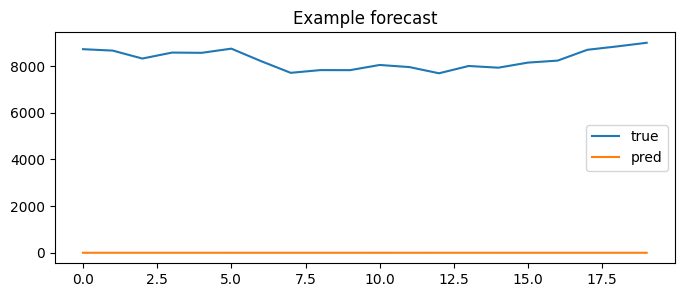

In [41]:
def evaluate_model_on_dataset(model, specs, targets, image_size=224, device=None):
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device).eval()
    ds = SpecForecastDataset(specs, targets, image_size=image_size)
    loader = DataLoader(ds, batch_size=16, shuffle=False, num_workers=2)
    preds=[]; trues=[]
    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)
            out = model(x).cpu().numpy()
            preds.append(out); trues.append(y.numpy())
    preds = np.vstack(preds); trues = np.vstack(trues)
    m_smape = smape(trues, preds)
    m_dir = direction_accuracy(trues, preds)
    # naive baseline: repeat last price (persistence) -> target baseline is last observed price repeated
    naive = np.tile(np.expand_dims(trues[:,0],1), (1,trues.shape[1]))
    m_mase = mean_absolute_error(trues, preds) / (np.mean(np.abs(np.diff(naive.flatten()))) + 1e-12)
    print("Eval: SMAPE:", m_smape, "Direction Acc:", m_dir, "MASE-like:", m_mase)
    return preds, trues

# load best model and eval
best_model = make_model(num_outputs=20, in_ch=1, use_vit=False)
best_model.load_state_dict(torch.load("out/model_best.pth", map_location='cpu'))
preds, trues = evaluate_model_on_dataset(best_model, np.load(SEQS_OUT)['specs'][:200], np.load(SEQS_OUT)['targets'][:200], image_size=224)
# plot one example
i=0
plt.figure(figsize=(8,3))
plt.plot(trues[i], label='true'); plt.plot(preds[i], label='pred'); plt.legend(); plt.title("Example forecast"); plt.show()

11) Inference helper: CSV → patterns + forecast (single function)

In [42]:
# Cell 11 — inference function
def infer_from_csv(model, csv_path_or_buffer, window=512, horizon=20, image_size=224, use_vit=False, device=None):
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    if isinstance(csv_path_or_buffer, (str,)):
        df = pd.read_csv(csv_path_or_buffer)
    else:
        df = pd.read_csv(io.BytesIO(csv_path_or_buffer))
    df.columns = [c.lower() for c in df.columns]
    # patterns
    ab = detect_advance_block(df); ds = detect_doji_star(df); es = detect_evening_star(df)
    patterns = {"advance_block": np.where(ab)[0].tolist(), "doji_star": np.where(ds)[0].tolist(), "evening_star": np.where(es)[0].tolist()}
    series = df['close'].values.astype(float)
    if len(series) < window:
        raise ValueError(f"Need at least {window} data points")
    hist = series[-window:]
    base = hist[-1]
    hist_norm = hist / (base + 1e-12)
    S = series_to_cwt_image(hist_norm)
    S_aug = add_intensity_row(S)
    img = cv2.resize(S_aug, (image_size, image_size)).astype('float32')
    img = (img - img.min()) / (img.max() - img.min() + 1e-12)
    x = torch.from_numpy(img[None, None, :, :]).float().to(device)
    model = model.to(device).eval()
    with torch.no_grad():
        out = model(x).cpu().numpy().ravel()
    return {"patterns": patterns, "forecast": out.tolist(), "last_price": float(base)}

# demo inference
res = infer_from_csv(best_model, str(csv_path))
print("Patterns (counts):", {k: len(v) for k,v in res['patterns'].items()})
print("Forecast (first 5):", res['forecast'][:5])

Patterns (counts): {'advance_block': 43, 'doji_star': 1515, 'evening_star': 245}
Forecast (first 5): [0.7527951598167419, 0.6972137093544006, 0.9007461667060852, 1.0420780181884766, 1.0263051986694336]
